# Latihan 1
Manual histogram equalization

In [1]:
import numpy as np

def manual_histogram_equalization(image):
    
    # 1. Hitung histogram
    hist = np.zeros(256)
    for pixel in image.flatten():
        hist[pixel] += 1

    # 2. Hitung cumulative histogram
    cdf = hist.cumsum()

    # 3. Hitung transformation function
    cdf_normalized = cdf / cdf[-1]
    transform = np.floor(255 * cdf_normalized).astype(np.uint8)

    # 4. Apply transformation
    equalized_image = transform[image]

    # 5. Return hasil
    return equalized_image, transform, hist

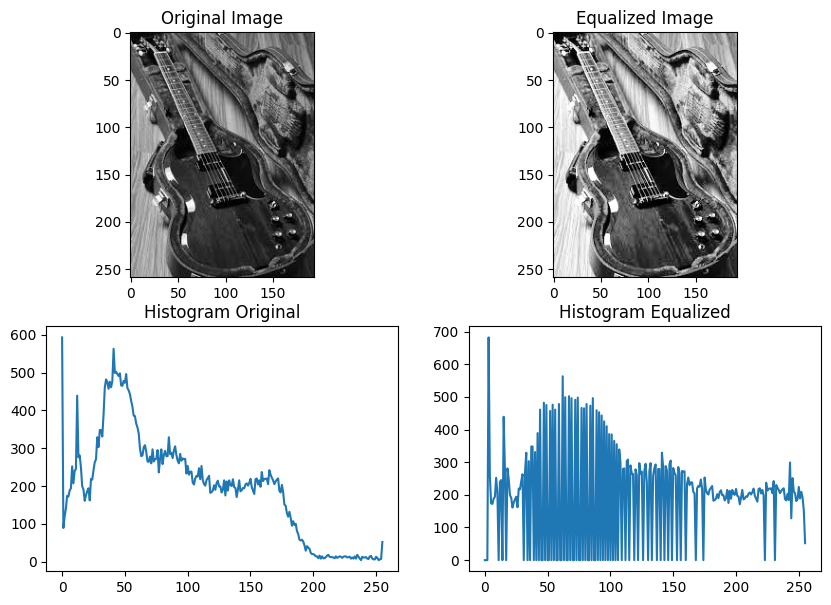

In [2]:
import cv2
import matplotlib.pyplot as plt

# baca gambar grayscale
img = cv2.imread("gambar.jpg", 0)

# jalankan fungsi
equalized, transform, hist = manual_histogram_equalization(img)

# hitung histogram hasil
hist_eq = np.zeros(256)
for pixel in equalized.flatten():
    hist_eq[pixel] += 1

# tampilkan gambar
plt.figure(figsize=(10,7))

plt.subplot(2,2,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')

plt.subplot(2,2,2)
plt.title("Equalized Image")
plt.imshow(equalized, cmap='gray')

# histogram sebelum
plt.subplot(2,2,3)
plt.title("Histogram Original")
plt.plot(hist)

# histogram sesudah
plt.subplot(2,2,4)
plt.title("Histogram Equalized")
plt.plot(hist_eq)

plt.show()

# Latihan 2
Medical image enhancement

In [3]:
import cv2
import numpy as np

def medical_image_enhancement(medical_image, modality='X-ray'):
    """
    Adaptive enhancement for medical images
    
    Parameters:
    medical_image: Input medical image
    modality: Image modality ('X-ray', 'MRI', 'CT', 'Ultrasound')
    
    Returns:
    Enhanced image and enhancement report
    """

    img = medical_image.copy()

    # pastikan grayscale
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ----- Enhancement berdasarkan modality -----

    if modality == 'X-ray':
        # Contrast enhancement
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(img)
        method = "CLAHE Contrast Enhancement"

    elif modality == 'MRI':
        # Noise reduction + contrast
        denoise = cv2.GaussianBlur(img,(5,5),0)
        enhanced = cv2.equalizeHist(denoise)
        method = "Gaussian Blur + Histogram Equalization"

    elif modality == 'CT':
        # Contrast stretching
        min_val = np.min(img)
        max_val = np.max(img)
        enhanced = ((img - min_val) / (max_val - min_val) * 255).astype(np.uint8)
        method = "Contrast Stretching"

    elif modality == 'Ultrasound':
        # Speckle noise reduction
        enhanced = cv2.medianBlur(img,5)
        method = "Median Filter (Speckle Noise Reduction)"

    else:
        enhanced = img
        method = "No Enhancement"

    # ----- Metrics untuk report -----

    mean_intensity = np.mean(enhanced)
    std_intensity = np.std(enhanced)
    contrast = enhanced.max() - enhanced.min()

    report = {
        "modality": modality,
        "method_used": method,
        "mean_intensity": float(mean_intensity),
        "std_intensity": float(std_intensity),
        "contrast": int(contrast)
    }

    return enhanced, report

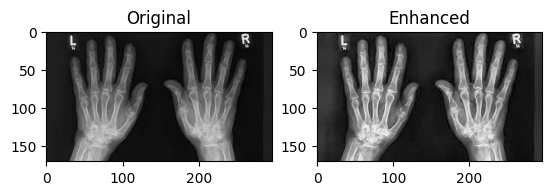

Enhancement Report:
{'modality': 'X-ray', 'method_used': 'CLAHE Contrast Enhancement', 'mean_intensity': 74.53591017488077, 'std_intensity': 60.56366841139192, 'contrast': 249}


In [4]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("xray.jpg",0)

enhanced, report = medical_image_enhancement(img, modality='X-ray')

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Enhanced")
plt.imshow(enhanced, cmap='gray')

plt.show()

print("Enhancement Report:")
print(report)

# Latihan 3
Real time enhancement


In [5]:
import cv2
import numpy as np
import time

class RealTimeEnhancement:
    
    def __init__(self, target_fps=30):
        self.target_fps = target_fps
        self.history_buffer = []
        self.max_buffer = 5   # batasi memory

    def enhance_frame(self, frame, enhancement_type='adaptive'):
        """
        Enhance single frame with real-time constraints
        
        Parameters:
        frame: Input video frame
        enhancement_type: Type of enhancement
        
        Returns:
        Enhanced frame
        """

        # 1. Convert ke grayscale jika perlu
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # 2. Enhancement ringan (real-time friendly)
        if enhancement_type == 'adaptive':
            
            # CLAHE (cepat dan stabil)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            enhanced = clahe.apply(gray)

        elif enhancement_type == 'denoise':
            
            # Median filter untuk noise
            enhanced = cv2.medianBlur(gray,3)

        else:
            enhanced = gray

        # 3. Temporal consistency
        self.history_buffer.append(enhanced)

        if len(self.history_buffer) > self.max_buffer:
            self.history_buffer.pop(0)

        # rata-rata beberapa frame sebelumnya
        temporal_avg = np.mean(self.history_buffer, axis=0).astype(np.uint8)

        return temporal_avg

In [ ]:
cap = cv2.VideoCapture(0)

enhancer = RealTimeEnhancement(target_fps=30)

while True:
    
    ret, frame = cap.read()
    if not ret:
        break

    enhanced_frame = enhancer.enhance_frame(frame)

    cv2.imshow("Original", frame)
    cv2.imshow("Enhanced", enhanced_frame)

    # keluar dengan tombol q
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

: 